In [50]:
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient

import os, getpass
from dotenv import load_dotenv
load_dotenv()

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("AZURE_OPENAI_API_KEY")
_set_env("AZURE_OPENAI_ENDPOINT")



In [51]:
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient
# Define a model client. You can use other model client that implements
# the `ChatCompletionClient` interface.
model_client = AzureOpenAIChatCompletionClient(
    model="gpt-4o",        
    api_version="2024-10-21",
    temperature=0
)

In [52]:
# Define a simple function tool that the agent can use.
# For this example, we use a fake weather tool for demonstration purposes.
async def get_weather(city: str) -> str:
    """Get the weather for a given city."""
    return f"The weather in {city} is 73 degrees and Sunny."


# Define an AssistantAgent with the model, tool, system message, and reflection enabled.
# The system message instructs the agent via natural language.
agent = AssistantAgent(
    name="weather_agent",
    model_client=model_client,
    tools=[get_weather],
    system_message="You are a helpful assistant.",
    reflect_on_tool_use=True,
    model_client_stream=True,  # Enable streaming tokens from the model client.
)


# # Run the agent and stream the messages to the console.
# async def main() -> None:
#     await Console(agent.run_stream(task="What is the weather in New York?"))
#     # Close the connection to the model client.
#     await model_client.close()


# # NOTE: if running this inside a Python script you'll need to use asyncio.run(main()).
# await main()

In [53]:
# Use asyncio.run(agent.run(...)) when running in a script.
result = await agent.run(task="What is the weather in New York?")
print(result)


messages=[TextMessage(source='user', models_usage=None, metadata={}, content='What is the weather in New York?', type='TextMessage'), ToolCallRequestEvent(source='weather_agent', models_usage=RequestUsage(prompt_tokens=0, completion_tokens=0), metadata={}, content=[FunctionCall(id='call_MkFIcQgfbwbThfMmNYmtsJy4', arguments='{"city":"New York"}', name='get_weather')], type='ToolCallRequestEvent'), ToolCallExecutionEvent(source='weather_agent', models_usage=None, metadata={}, content=[FunctionExecutionResult(content='The weather in New York is 73 degrees and Sunny.', name='get_weather', call_id='call_MkFIcQgfbwbThfMmNYmtsJy4', is_error=False)], type='ToolCallExecutionEvent'), TextMessage(source='weather_agent', models_usage=RequestUsage(prompt_tokens=0, completion_tokens=0), metadata={}, content='The weather in New York is currently 73°F and sunny. Perfect for outdoor activities!', type='TextMessage')] stop_reason=None


In [54]:
for message in result.messages:
    print(message)

source='user' models_usage=None metadata={} content='What is the weather in New York?' type='TextMessage'
source='weather_agent' models_usage=RequestUsage(prompt_tokens=0, completion_tokens=0) metadata={} content=[FunctionCall(id='call_MkFIcQgfbwbThfMmNYmtsJy4', arguments='{"city":"New York"}', name='get_weather')] type='ToolCallRequestEvent'
source='weather_agent' models_usage=None metadata={} content=[FunctionExecutionResult(content='The weather in New York is 73 degrees and Sunny.', name='get_weather', call_id='call_MkFIcQgfbwbThfMmNYmtsJy4', is_error=False)] type='ToolCallExecutionEvent'
source='weather_agent' models_usage=RequestUsage(prompt_tokens=0, completion_tokens=0) metadata={} content='The weather in New York is currently 73°F and sunny. Perfect for outdoor activities!' type='TextMessage'


In [55]:
async def assistant_run_stream() -> None:
    # Option 1: read each message from the stream (as shown in the previous example).
    # async for message in agent.run_stream(task="Find information on AutoGen"):
    #     print(message)

    # Option 2: use Console to print all messages as they appear.
    await Console(
        agent.run_stream(task="What is the weather in New York?"),
        output_stats=True,  # Enable stats printing.
    )


# Use asyncio.run(assistant_run_stream()) when running in a script.
await assistant_run_stream()


---------- TextMessage (user) ----------
What is the weather in New York?
---------- ModelClientStreamingChunkEvent (weather_agent) ----------
The weather in New York is currently 73°F and sunny.
[Prompt tokens: 0, Completion tokens: 0]
---------- Summary ----------
Number of messages: 2
Finish reason: None
Total prompt tokens: 0
Total completion tokens: 0
Duration: 1.79 seconds



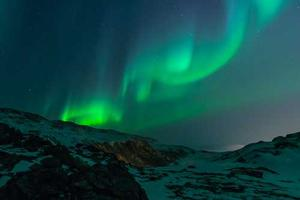

In [56]:
from io import BytesIO

import PIL
import requests
from autogen_agentchat.messages import MultiModalMessage
from autogen_core import Image

# Create a multi-modal message with random image and text.
pil_image = PIL.Image.open(BytesIO(requests.get("https://picsum.photos/300/200").content))
img = Image(pil_image)
multi_modal_message = MultiModalMessage(content=["Can you describe the content of this image?", img], source="user")
img


In [57]:
# Use asyncio.run(...) when running in a script.
result = await agent.run(task=multi_modal_message)
print(result.messages[-1].content)  # type: ignore


This image showcases the stunning natural phenomenon known as the Northern Lights, or Aurora Borealis. Bright green and blue lights dance across the night sky, creating a mesmerizing display. The foreground features a snowy, rocky landscape, adding to the serene and magical atmosphere of the scene.


In [58]:
from autogen_core.tools import FunctionTool


# Define a tool using a Python function.
async def web_search_func(query: str) -> str:
    """Find information on the web"""
    return "AutoGen is a programming framework for building multi-agent applications."


# This step is automatically performed inside the AssistantAgent if the tool is a Python function.
web_search_function_tool = FunctionTool(web_search_func, description="Find information on the web")
# The schema is provided to the model during AssistantAgent's on_messages call.
web_search_function_tool.schema


{'name': 'web_search_func',
 'description': 'Find information on the web',
 'parameters': {'type': 'object',
  'properties': {'query': {'description': 'query',
    'title': 'Query',
    'type': 'string'}},
  'required': ['query'],
  'additionalProperties': False},
 'strict': False}

In [59]:
from typing import Literal

from pydantic import BaseModel
from autogen_agentchat.messages import StructuredMessage


# The response format for the agent as a Pydantic base model.
class AgentResponse(BaseModel):
    thoughts: str
    response: Literal["happy", "sad", "neutral"]


# Create an agent that uses the OpenAI GPT-4o model.
agent = AssistantAgent(
    "assistant",
    model_client=model_client,
    system_message="Categorize the input as happy, sad, or neutral following the JSON format.",
    # Define the output content type of the agent.
    output_content_type=AgentResponse,
)

result = await Console(agent.run_stream(task="I am happy."))

# Check the last message in the result, validate its type, and print the thoughts and response.
assert isinstance(result.messages[-1], StructuredMessage)
assert isinstance(result.messages[-1].content, AgentResponse)
print("Thought: ", result.messages[-1].content.thoughts)
print("Response: ", result.messages[-1].content.response)
await model_client.close()


---------- TextMessage (user) ----------
I am happy.
---------- StructuredMessage[AgentResponse] (assistant) ----------
{"thoughts":"The user expressed happiness directly.","response":"happy"}
Thought:  The user expressed happiness directly.
Response:  happy


In [60]:
import asyncio

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.base import TaskResult
from autogen_agentchat.conditions import ExternalTermination, TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console
from autogen_core import CancellationToken
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient

# Create an OpenAI model client.
model_client = AzureOpenAIChatCompletionClient(
    model="gpt-4o",        
    api_version="2024-10-21",
    temperature=0
)

# Create the primary agent.
primary_agent = AssistantAgent(
    "primary",
    model_client=model_client,
    system_message="You are a helpful AI assistant.",
)

# Create the critic agent.
critic_agent = AssistantAgent(
    "critic",
    model_client=model_client,
    system_message="Provide constructive feedback. Respond with 'APPROVE' to when your feedbacks are addressed.",
)

# Define a termination condition that stops the task if the critic approves.
text_termination = TextMentionTermination("APPROVE")

# Create a team with the primary and critic agents.
team = RoundRobinGroupChat([primary_agent, critic_agent], termination_condition=text_termination)


In [61]:
# When running inside a script, use a async main function and call it from `asyncio.run(...)`.
await team.reset()  # Reset the team for a new task.
async for message in team.run_stream(task="Write a short poem about the fall season."):  # type: ignore
    if isinstance(message, TaskResult):
        print("Stop Reason:", message.stop_reason)
    else:
        print(message)


source='user' models_usage=None metadata={} content='Write a short poem about the fall season.' type='TextMessage'
source='primary' models_usage=RequestUsage(prompt_tokens=28, completion_tokens=77) metadata={} content="**Whispers of Fall**  \n\nGolden leaves drift through the air,  \nAutumn's touch is everywhere.  \nCrisp winds hum a gentle tune,  \nBeneath the glow of harvest moon.  \n\nPumpkin scents and apple cheer,  \nThe cozy time of year is here.  \nNature dons its fiery shawl,  \nIn the fleeting grace of fall.  " type='TextMessage'
source='critic' models_usage=RequestUsage(prompt_tokens=122, completion_tokens=135) metadata={} content='Your poem beautifully captures the essence of fall with vivid imagery and a warm, inviting tone. The use of phrases like "Golden leaves drift through the air" and "Nature dons its fiery shawl" paints a picturesque scene that resonates with the season\'s charm. The rhythm flows smoothly, and the rhyme scheme adds a pleasant musicality to the piece. 

In [62]:
await team.reset()  # Reset the team for a new task.
await Console(team.run_stream(task="Write a short poem about the fall season."))  # Stream the messages to the console.


---------- TextMessage (user) ----------
Write a short poem about the fall season.
---------- TextMessage (primary) ----------
**Whispers of Fall**  

Golden leaves drift through the air,  
Autumn's touch is everywhere.  
Crisp winds hum a gentle tune,  
Beneath the glow of harvest moon.  

Pumpkin scents and apple spice,  
Sweaters warm, the chill feels nice.  
Nature dons its fiery hue,  
A fleeting beauty, bold and true.  

In fall's embrace, the world slows down,  
A quiet peace in amber's crown.  
Moments linger, hearts grow full,  
The season's magic, soft and cool.  
---------- TextMessage (critic) ----------
Your poem beautifully captures the essence of fall with vivid imagery and a soothing rhythm. The use of sensory details like "pumpkin scents and apple spice" and "crisp winds hum a gentle tune" immerses the reader in the season's atmosphere. The structure flows well, and the rhymes feel natural, enhancing the poem's charm.  

One suggestion for improvement could be to explo

TaskResult(messages=[TextMessage(source='user', models_usage=None, metadata={}, content='Write a short poem about the fall season.', type='TextMessage'), TextMessage(source='primary', models_usage=RequestUsage(prompt_tokens=28, completion_tokens=117), metadata={}, content="**Whispers of Fall**  \n\nGolden leaves drift through the air,  \nAutumn's touch is everywhere.  \nCrisp winds hum a gentle tune,  \nBeneath the glow of harvest moon.  \n\nPumpkin scents and apple spice,  \nSweaters warm, the chill feels nice.  \nNature dons its fiery hue,  \nA fleeting beauty, bold and true.  \n\nIn fall's embrace, the world slows down,  \nA quiet peace in amber's crown.  \nMoments linger, hearts grow full,  \nThe season's magic, soft and cool.  ", type='TextMessage'), TextMessage(source='critic', models_usage=RequestUsage(prompt_tokens=162, completion_tokens=128), metadata={}, content='Your poem beautifully captures the essence of fall with vivid imagery and a soothing rhythm. The use of sensory de

In [63]:
await team.reset()  # Reset the team for the next run.


In [64]:
# Create a new team with an external termination condition.
external_termination = ExternalTermination()
team = RoundRobinGroupChat(
    [primary_agent, critic_agent],
    termination_condition=external_termination | text_termination,  # Use the bitwise OR operator to combine conditions.
)

# Run the team in a background task.
run = asyncio.create_task(Console(team.run_stream(task="Write a short poem about the fall season.")))

# Wait for some time.
await asyncio.sleep(0.1)

# Stop the team.
external_termination.set()

# Wait for the team to finish.
await run


---------- TextMessage (user) ----------
Write a short poem about the fall season.
---------- TextMessage (primary) ----------
**Whispers of Fall**  

Golden leaves drift through the air,  
Autumn's touch is everywhere.  
Crisp winds hum a gentle tune,  
Beneath the glow of harvest moon.  

Pumpkin scents and apple spice,  
Sweaters warm, the chill feels nice.  
Nature dons its fiery hue,  
A fleeting beauty, bold and true.  

In fall's embrace, the world slows down,  
A quiet peace in amber's crown.  
A season's end, yet life's refrain—  
The promise of spring will come again.  


TaskResult(messages=[TextMessage(source='user', models_usage=None, metadata={}, content='Write a short poem about the fall season.', type='TextMessage'), TextMessage(source='primary', models_usage=RequestUsage(prompt_tokens=28, completion_tokens=117), metadata={}, content="**Whispers of Fall**  \n\nGolden leaves drift through the air,  \nAutumn's touch is everywhere.  \nCrisp winds hum a gentle tune,  \nBeneath the glow of harvest moon.  \n\nPumpkin scents and apple spice,  \nSweaters warm, the chill feels nice.  \nNature dons its fiery hue,  \nA fleeting beauty, bold and true.  \n\nIn fall's embrace, the world slows down,  \nA quiet peace in amber's crown.  \nA season's end, yet life's refrain—  \nThe promise of spring will come again.  ", type='TextMessage')], stop_reason='External termination requested')

In [65]:
await Console(team.run_stream())  # Resume the team to continue the last task.


---------- TextMessage (critic) ----------
Your poem beautifully captures the essence of fall with vivid imagery and a soothing rhythm. The use of sensory details like "pumpkin scents and apple spice" and "crisp winds hum a gentle tune" creates a warm and inviting atmosphere. The cyclical theme of seasons transitioning is poignant and adds depth to the piece.  

One suggestion for improvement could be to explore a unique perspective or metaphor that sets your poem apart from traditional fall imagery. For example, you might liken the falling leaves to pages of a story being written or the changing colors to a painter's masterpiece.  

Let me know if you'd like to refine or expand the poem further!
---------- TextMessage (primary) ----------
Thank you for the thoughtful critique! I appreciate your suggestion to incorporate a unique perspective or metaphor to deepen the imagery. Here's a refined version of the poem with that idea in mind:

**Autumn's Canvas**  

Leaves descend like pages 

TaskResult(messages=[TextMessage(source='critic', models_usage=RequestUsage(prompt_tokens=162, completion_tokens=130), metadata={}, content='Your poem beautifully captures the essence of fall with vivid imagery and a soothing rhythm. The use of sensory details like "pumpkin scents and apple spice" and "crisp winds hum a gentle tune" creates a warm and inviting atmosphere. The cyclical theme of seasons transitioning is poignant and adds depth to the piece.  \n\nOne suggestion for improvement could be to explore a unique perspective or metaphor that sets your poem apart from traditional fall imagery. For example, you might liken the falling leaves to pages of a story being written or the changing colors to a painter\'s masterpiece.  \n\nLet me know if you\'d like to refine or expand the poem further!', type='TextMessage'), TextMessage(source='primary', models_usage=RequestUsage(prompt_tokens=283, completion_tokens=170), metadata={}, content="Thank you for the thoughtful critique! I appre

In [66]:
# The new task is to translate the same poem to Chinese Tang-style poetry.
await Console(team.run_stream(task="将这首诗用中文唐诗风格写一遍。"))


---------- TextMessage (user) ----------
将这首诗用中文唐诗风格写一遍。
---------- TextMessage (primary) ----------
**秋韵**  

霜叶飘落书页残，  
丹青妙笔绘山川。  
风吟低诉诗千句，  
桂酒香浓梦未阑。  

夕照染空霞作锦，  
终章未尽意绵绵。  
秋去春来循旧路，  
万物轮回自悠然。  

希望这唐诗风格的改编能传递出秋季的意境之美！如果有任何修改建议，请随时告诉我。
---------- TextMessage (critic) ----------
这首唐诗风格的改编非常优美，成功地捕捉了秋季的意境，同时保留了原诗的主题和情感。用“霜叶飘落书页残”来比喻落叶如书页，既形象又富有诗意；“风吟低诉诗千句”赋予了风以生命和情感，增添了诗的灵动感。结尾“秋去春来循旧路，万物轮回自悠然”更是点明了自然的循环与生命的哲理，余韵悠长。

唯一的小建议是，若想更贴近唐诗的韵律，可以稍微调整用词或句式，使其更加符合平仄格律的要求。不过，这已经是一首非常出色的作品了！

如果需要进一步调整，请告诉我！否则，我会标记为 **APPROVE**。


TaskResult(messages=[TextMessage(source='user', models_usage=None, metadata={}, content='将这首诗用中文唐诗风格写一遍。', type='TextMessage'), TextMessage(source='primary', models_usage=RequestUsage(prompt_tokens=588, completion_tokens=116), metadata={}, content='**秋韵**  \n\n霜叶飘落书页残，  \n丹青妙笔绘山川。  \n风吟低诉诗千句，  \n桂酒香浓梦未阑。  \n\n夕照染空霞作锦，  \n终章未尽意绵绵。  \n秋去春来循旧路，  \n万物轮回自悠然。  \n\n希望这唐诗风格的改编能传递出秋季的意境之美！如果有任何修改建议，请随时告诉我。', type='TextMessage'), TextMessage(source='critic', models_usage=RequestUsage(prompt_tokens=721, completion_tokens=203), metadata={}, content='这首唐诗风格的改编非常优美，成功地捕捉了秋季的意境，同时保留了原诗的主题和情感。用“霜叶飘落书页残”来比喻落叶如书页，既形象又富有诗意；“风吟低诉诗千句”赋予了风以生命和情感，增添了诗的灵动感。结尾“秋去春来循旧路，万物轮回自悠然”更是点明了自然的循环与生命的哲理，余韵悠长。\n\n唯一的小建议是，若想更贴近唐诗的韵律，可以稍微调整用词或句式，使其更加符合平仄格律的要求。不过，这已经是一首非常出色的作品了！\n\n如果需要进一步调整，请告诉我！否则，我会标记为 **APPROVE**。', type='TextMessage')], stop_reason="Text 'APPROVE' mentioned")

In [67]:
# The new task is to translate the same poem to Chinese Tang-style poetry.
await Console(team.run_stream(task="translate the poem to Hindi poetry."))

---------- TextMessage (user) ----------
translate the poem to Hindi poetry.
---------- TextMessage (primary) ----------
**शरद की छवि**  

पत्ते गिरें, जैसे पन्ने पुराने,  
प्रकृति लिखे अपनी कहानी।  
रंगों से सजी चित्रकारी,  
हर क्षण में छुपी है प्यारी।  

हवा गाए मधुर गीत,  
सुनाए ऋतु की अनोखी प्रीत।  
सुगंधित है सेब और चाय,  
शरद का जादू मन को भाए।  

सूरज ढले, आकाश सजे,  
अंत में भी आशा बचे।  
शरद विदा, वसंत फिर आए,  
जीवन चक्र यूं ही चल जाए।  

यह हिंदी कविता शरद ऋतु की सुंदरता और जीवन के चक्र को दर्शाती है। यदि आप इसमें कोई बदलाव चाहते हैं, तो मुझे बताएं!
---------- TextMessage (critic) ----------
यह हिंदी अनुवाद बहुत ही सुंदर और भावपूर्ण है। आपने मूल कविता की आत्मा को बखूबी हिंदी में उतारा है। "पत्ते गिरें, जैसे पन्ने पुराने" और "हवा गाए मधुर गीत" जैसे वाक्यांशों ने कविता को एक गहरी संवेदनशीलता और काव्यात्मकता दी है। अंत में "शरद विदा, वसंत फिर आए" जीवन के चक्र और ऋतु परिवर्तन की भावना को खूबसूरती से व्यक्त करता है।  

यदि कोई सुझाव देना हो, तो वह यह होगा कि कविता में छंद और लय क

TaskResult(messages=[TextMessage(source='user', models_usage=None, metadata={}, content='translate the poem to Hindi poetry.', type='TextMessage'), TextMessage(source='primary', models_usage=RequestUsage(prompt_tokens=927, completion_tokens=181), metadata={}, content='**शरद की छवि**  \n\nपत्ते गिरें, जैसे पन्ने पुराने,  \nप्रकृति लिखे अपनी कहानी।  \nरंगों से सजी चित्रकारी,  \nहर क्षण में छुपी है प्यारी।  \n\nहवा गाए मधुर गीत,  \nसुनाए ऋतु की अनोखी प्रीत।  \nसुगंधित है सेब और चाय,  \nशरद का जादू मन को भाए।  \n\nसूरज ढले, आकाश सजे,  \nअंत में भी आशा बचे।  \nशरद विदा, वसंत फिर आए,  \nजीवन चक्र यूं ही चल जाए।  \n\nयह हिंदी कविता शरद ऋतु की सुंदरता और जीवन के चक्र को दर्शाती है। यदि आप इसमें कोई बदलाव चाहते हैं, तो मुझे बताएं!', type='TextMessage'), TextMessage(source='critic', models_usage=RequestUsage(prompt_tokens=1125, completion_tokens=205), metadata={}, content='यह हिंदी अनुवाद बहुत ही सुंदर और भावपूर्ण है। आपने मूल कविता की आत्मा को बखूबी हिंदी में उतारा है। "पत्ते गिरें, जैसे पन्ने 

In [68]:
# Create a cancellation token.
cancellation_token = CancellationToken()

# Use another coroutine to run the team.
run = asyncio.create_task(
    team.run(
        task="Translate the poem to Spanish.",
        cancellation_token=cancellation_token,
    )
)

# Cancel the run.
cancellation_token.cancel()

try:
    result = await run  # This will raise a CancelledError.
except asyncio.CancelledError:
    print("Task was cancelled.")


Task was cancelled.


In [69]:
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import TextMessageTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient

# Create an OpenAI model client.
model_client = AzureOpenAIChatCompletionClient(
    model="gpt-4o",        
    api_version="2024-10-21",
    temperature=0
)


# Create a tool for incrementing a number.
def increment_number(number: int) -> int:
    """Increment a number by 1."""
    return number + 1


# Create a tool agent that uses the increment_number function.
looped_assistant = AssistantAgent(
    "looped_assistant",
    model_client=model_client,
    tools=[increment_number],  # Register the tool.
    system_message="You are a helpful AI assistant, use the tool to increment the number.",
)

# Termination condition that stops the task if the agent responds with a text message.
termination_condition = TextMessageTermination("looped_assistant")

# Create a team with the looped assistant agent and the termination condition.
team = RoundRobinGroupChat(
    [looped_assistant],
    termination_condition=termination_condition,
)

# Run the team with a task and print the messages to the console.
async for message in team.run_stream(task="Increment the number 5 to 10."):  # type: ignore
    print(type(message).__name__, message)

await model_client.close()


TextMessage source='user' models_usage=None metadata={} content='Increment the number 5 to 10.' type='TextMessage'
ToolCallRequestEvent source='looped_assistant' models_usage=RequestUsage(prompt_tokens=75, completion_tokens=87) metadata={} content=[FunctionCall(id='call_Cds0U2dtH3ggxunVhJ5BN3QJ', arguments='{"number": 5}', name='increment_number'), FunctionCall(id='call_4Nj97UEY06qPiVz14duDmFft', arguments='{"number": 6}', name='increment_number'), FunctionCall(id='call_o52KQa1Cz7Y8VvygxWSz9MIz', arguments='{"number": 7}', name='increment_number'), FunctionCall(id='call_tdpMtCUe5JdnLpBhii4BH5Wz', arguments='{"number": 8}', name='increment_number'), FunctionCall(id='call_vJGPVlFIpKSvKjqlCXXteA1W', arguments='{"number": 9}', name='increment_number')] type='ToolCallRequestEvent'
ToolCallExecutionEvent source='looped_assistant' models_usage=None metadata={} content=[FunctionExecutionResult(content='6', name='increment_number', call_id='call_Cds0U2dtH3ggxunVhJ5BN3QJ', is_error=False), Funct

In [70]:
from autogen_agentchat.agents import AssistantAgent, UserProxyAgent
from autogen_agentchat.conditions import TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient

# Create an OpenAI model client.
model_client = AzureOpenAIChatCompletionClient(
    model="gpt-4o",        
    api_version="2024-10-21",
    temperature=0
)

assistant = AssistantAgent("assistant", model_client=model_client)
user_proxy = UserProxyAgent("user_proxy", input_func=input)  # Use input() to get user input from console.

# Create the termination condition which will end the conversation when the user says "APPROVE".
termination = TextMentionTermination("APPROVE")

# Create the team.
team = RoundRobinGroupChat([assistant, user_proxy], termination_condition=termination)

# Run the conversation and stream to the console.
stream = team.run_stream(task="Write a 4-line poem about the ocean.")
# Use asyncio.run(...) when running in a script.
await Console(stream)
await model_client.close()


---------- TextMessage (user) ----------
Write a 4-line poem about the ocean.
---------- TextMessage (assistant) ----------
Beneath the waves, a world untold,  
A dance of blue, both fierce and bold.  
Its whispers call, a timeless tune,  
The ocean hums beneath the moon.  

TERMINATE
---------- TextMessage (user_proxy) ----------
longer
---------- TextMessage (assistant) ----------
Beneath the waves, a world untold,  
A dance of blue, both fierce and bold.  
Its whispers call, a timeless tune,  
The ocean hums beneath the moon.  

Its depths conceal both life and lore,  
A boundless realm, forevermore.  
The tides embrace the shore with grace,  
A ceaseless rhythm, time can't erase.  

TERMINATE
---------- TextMessage (user_proxy) ----------
APPROVE
